# IBM Telco Customer Churn EDA

Exploration of the dataset used by the training pipeline.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(project_root))

from src.features import build_features, load_raw_data

raw = pd.read_csv(project_root / 'data' / 'raw' / 'telco_churn.csv')
df = load_raw_data(project_root / 'data' / 'raw' / 'telco_churn.csv')

2026-10-01 16:58:28 | src.features                 | INFO     | Loaded 7043 rows from /Users/harshajoshi/Documents/Projects/Data Science/churn_platform/data/raw/telco_churn.csv


## Dataset overview

In [2]:
print(f'Rows: {len(raw):,}')
print(f'Columns: {raw.shape[1]}')
print(f'Duplicate customer IDs: {raw["customerID"].duplicated().sum()}')
missing_values = raw.replace(r'^\s*$', pd.NA, regex=True).isna().sum().sum()
print(f'Missing values: {missing_values}')
raw.head()

Rows: 7,043
Columns: 21
Duplicate customer IDs: 0
Missing values: 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Churn distribution

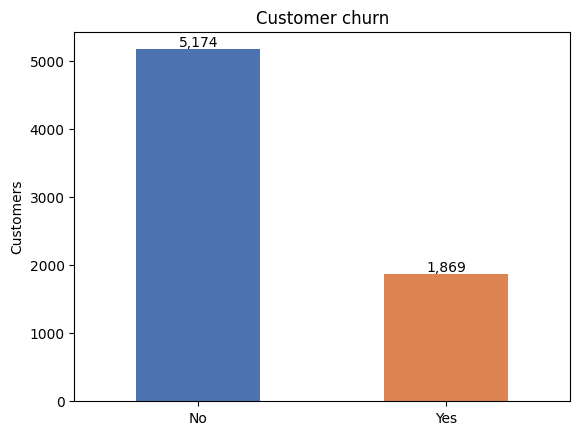

Churn rate: 26.5%


In [3]:
churn_counts = raw['Churn'].value_counts().reindex(['No', 'Yes'])
ax = churn_counts.plot.bar(color=['#4C72B0', '#DD8452'], rot=0)
ax.set(title='Customer churn', xlabel='', ylabel='Customers')
for bar, value in zip(ax.patches, churn_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, value, f'{value:,}', ha='center', va='bottom')
plt.show()
print(f'Churn rate: {(raw["Churn"] == "Yes").mean():.1%}')

## Numeric features

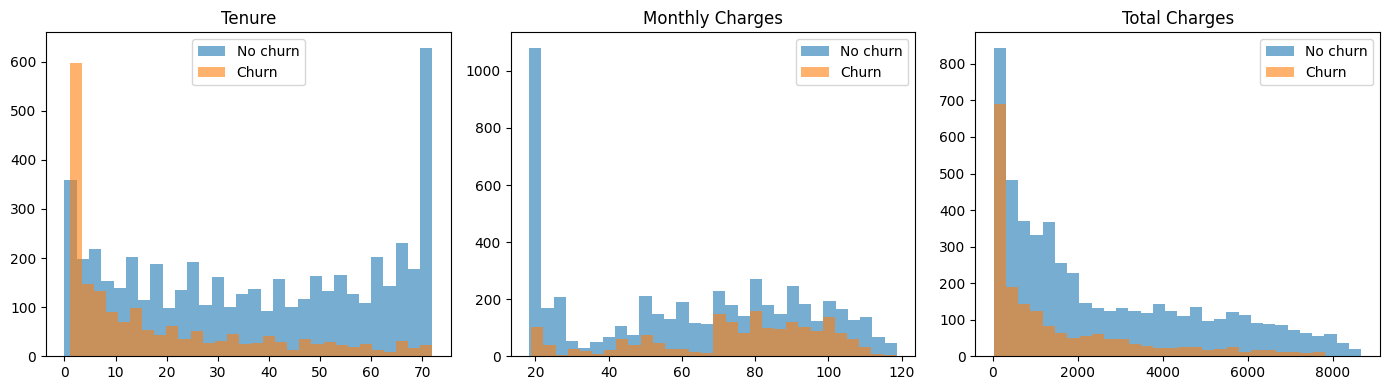

In [4]:
numeric_columns = ['tenure', 'monthly_charges', 'total_charges']
labels = df['churn'].map({0: 'No churn', 1: 'Churn'})
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for column, ax in zip(numeric_columns, axes):
    for label in ['No churn', 'Churn']:
        ax.hist(df.loc[labels == label, column], bins=30, alpha=0.6, label=label)
    ax.set_title(column.replace('_', ' ').title())
    ax.legend()

plt.tight_layout()
plt.show()

## Churn by category

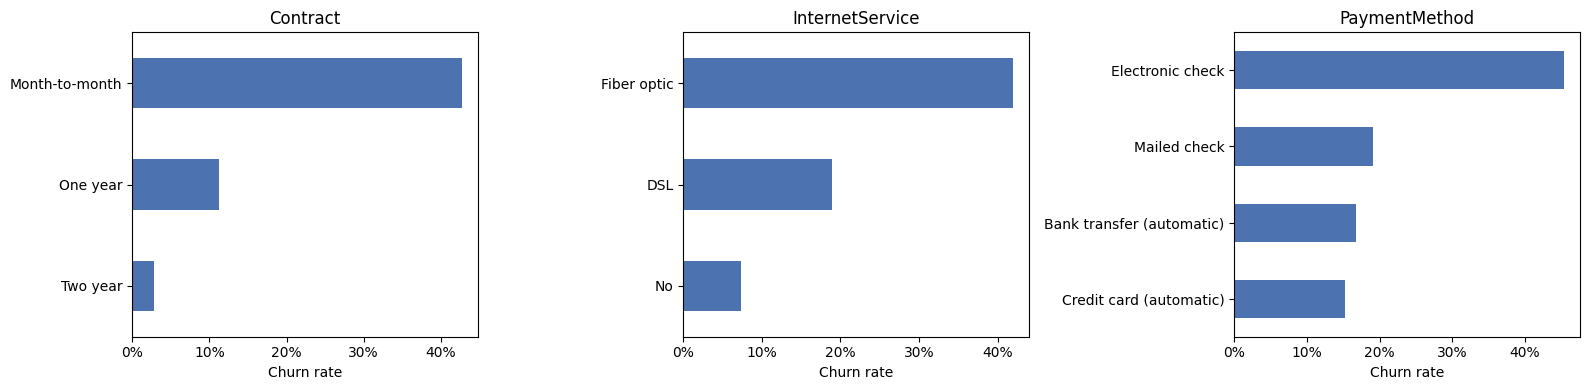

In [5]:
categorical_columns = ['Contract', 'InternetService', 'PaymentMethod']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for column, ax in zip(categorical_columns, axes):
    rates = raw.groupby(column)['Churn'].apply(lambda values: values.eq('Yes').mean()).sort_values()
    rates.plot.barh(ax=ax, color='#4C72B0')
    ax.set(title=column, xlabel='Churn rate', ylabel='')
    ax.xaxis.set_major_formatter(lambda value, _: f'{value:.0%}')

plt.tight_layout()
plt.show()

## Feature relationships

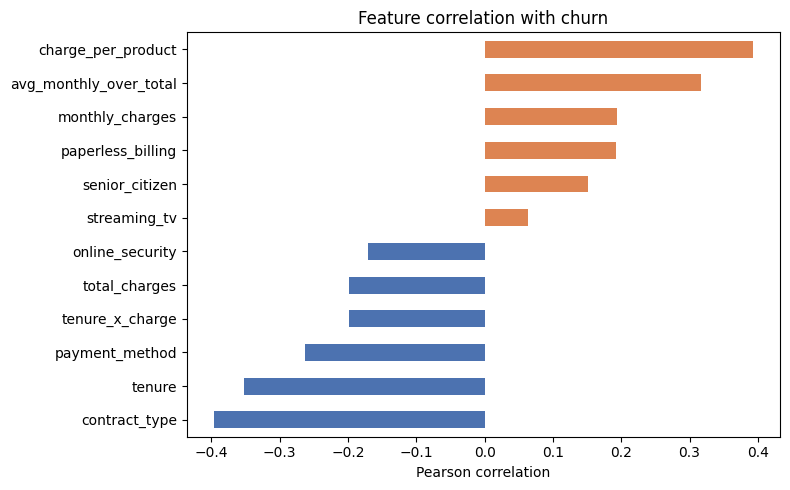

In [6]:
features = build_features(df)
correlations = (
    features.drop(columns='customer_id')
    .corr(numeric_only=True)['churn']
    .drop('churn')
    .sort_values()
)

strongest = pd.concat([correlations.head(6), correlations.tail(6)]).drop_duplicates()
colors = ['#4C72B0' if value < 0 else '#DD8452' for value in strongest]
ax = strongest.plot.barh(figsize=(8, 5), color=colors)
ax.set(title='Feature correlation with churn', xlabel='Pearson correlation', ylabel='')
plt.tight_layout()
plt.show()

## Findings

- Month-to-month customers have the highest observed churn rate.
- Customers who churn have shorter average tenure and higher monthly charges.
- Fiber-optic customers and electronic-check users have higher observed churn rates.
- These are associations in the dataset, not causal effects.